# Matrix and vector manipulations

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In some cases, matrices and vectors are composed of sub-matrices or sub-vectors. In another cases we may want to 'reshape' a matrix, or reshape a vector into a matrix, or vice versa.
We can conveniently do such operations using some standard numpy functions:
- `np.block` to create a matrix from sub-matrices
- `np.concatenate` to combine two or more vectors into one vector
- `np.reshape` to change the shape of a matrix


Let's go over a some exercises to see how to manipulate matrices and vectors using these functions.

> **Task 1:**
>
> Run the code below to create four different matrices and combine these into a single matrix.
>
> Complete the code to extract the top row of matrix A1 into vector b1 and the top row of matrix A2 into vector b2.

In [28]:
A11 = np.array([
    [1, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 0],
    [1, 0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1, 0],
    [1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0]])

A12 = np.array([
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]])

A21 = A12.transpose().copy()
A21[1:4,0] = 1

A22 = np.array([
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1]])

print(A21)

[[1 1 1 1 0 0]
 [1 0 0 0 1 0]
 [1 0 0 0 1 0]
 [1 0 0 0 1 0]
 [1 1 1 1 0 0]]


In [39]:
# print(A11[0, 0:6])
b1 = A11[0, 0:6]
b2 = A12[0, 0:5]
print(b1, b2)

[1 0 0 0 1 0] [1 0 0 0 1]


> **Task 2:**
>
> Run the code below to create a single matrix A from the four sub-matrices and combine the two b-vectors into a single vector b. Print vector b and plot matrix A using plt.matshow.

[1 0 0 0 1 0 1 0 0 0 1]


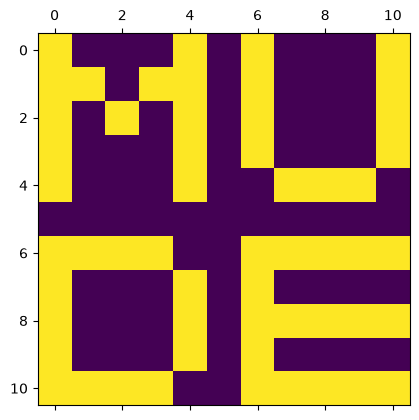

In [40]:
A = np.block([[A11, A12],
              [A21, A22]])

b = np.concatenate([b1, b2])

print(b)
plt.matshow(A)
plt.show()

Now, we will use the `np.reshape` function to change the shape of a matrix.

Reshape puts all matrix components row-by-row behind each other in a long vector and then recreates the matrix according to the new shape by taking row-by-row from the long vector.

> **Task 3:**
>
> Run the code below to change the shape of the matrix A11 and A21, and plot the resuls using plt.matshow.

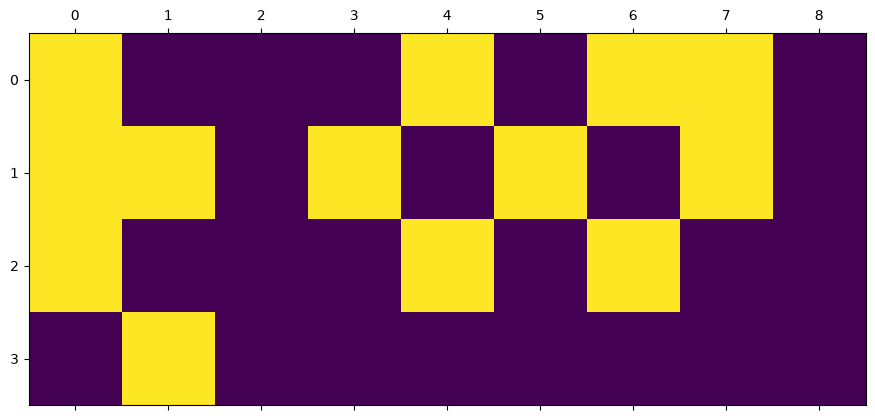

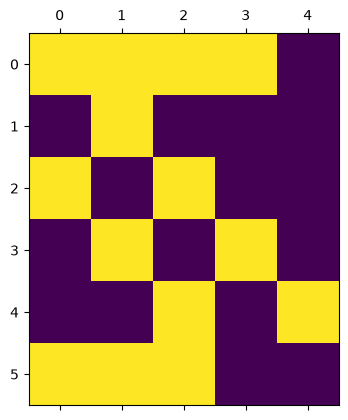

In [46]:
A11 = A11.reshape(4,9)
plt.matshow(A11)
A21 = A21.reshape(6,5)
plt.matshow(A21)
plt.show()

Note that the results look quite different than the original (sub-)matrices, and the operation seems quite useless. Nevertheless, in some situations it might be useful to perform operations on a vector and reshape the result back into matrix, as we will see later on in MUDE.

> **Task 4:**
>
> Play with the reshape function yourself. Note that the total number of elements in the original matrix and the reshaped matrix must remain equal.

> By Ronald Brinkgreve, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).

Text(0, 0.5, 'concentration')

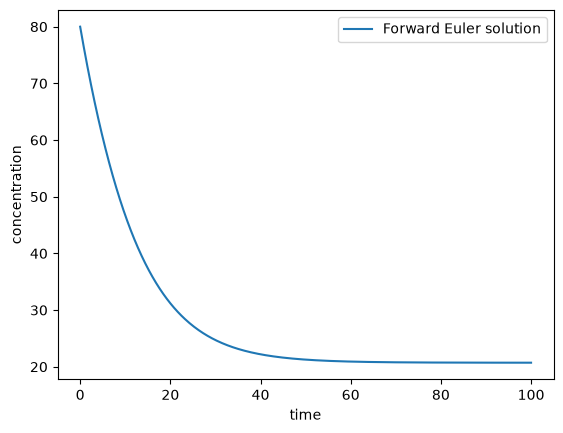

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# set up time vector
dt = 0.2
t_end = 100
n_times = int(t_end / dt)
t = np.linspace(0, t_end, num=n_times)

# parameter values
c0 = 80.0
K = 50.0
c_in = 50.0
r_max = 5.0
Q = 0.1
V = 2.0

##-----------------------------
##Explicit Euler Implementation
##-----------------------------
c = [c0]
for i in range(n_times - 1):
    c_i = c[-1]
    dcdt = Q / V * (c_in - c_i) - r_max * c_i / (c_i + K)
    c.append(c_i + dt * dcdt)
##------------------------------

plt.plot(t, c)
plt.legend(["Forward Euler solution"])
plt.xlabel("time")
plt.ylabel("concentration")

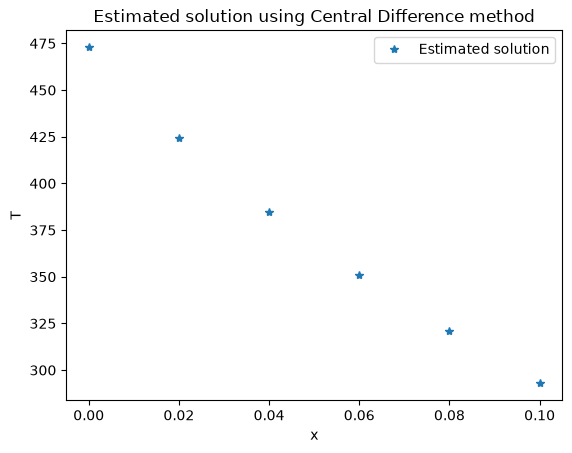

The estimated temperature at the nodes are: ['473.00', '424.46', '384.64', '350.91', '321.02', '293.00'] [K]


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# define the parameters
dx = 0.02
Ts = 293
alpha = 166

# precompute elements of the matrix A and vector b
matrix_element = -(2 + dx**2 * alpha)
b_element = -(dx**2) * alpha * Ts

# grid creation
x = np.arange(0, 0.1 + dx, dx)
T = np.zeros(x.shape)

# boundary conditions
T[0] = 473
T[-1] = 293

# build the matrix A
A = np.zeros((len(x) - 2, len(x) - 2))
np.fill_diagonal(A, matrix_element) # fill the main diagonal
A[np.arange(3), np.arange(1, 4)] = 1  # fill the upper diagonal
A[np.arange(1, 4), np.arange(3)] = 1  # fill the lower diagonal

# build the vector b
b = np.array([b_element - T[0], b_element, b_element, b_element - T[-1]])

# solve the system of equations
T[1:-1] = np.linalg.solve(A, b)

# plot the solution
plt.plot(x, T, "*", label="Estimated solution")
plt.xlabel("x")
plt.ylabel("T")
plt.title("Estimated solution using Central Difference method")
plt.legend()
plt.show()

print(
    f"The estimated temperature at the nodes are: {[f'{temp:.2f}' for temp in T]} [K]"
)